1.0
-0.0
0.7219280948873623


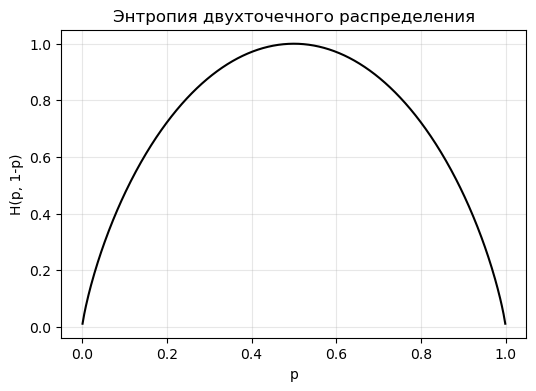

2.584962500721156
2.584962500721156
-0.0
2.0


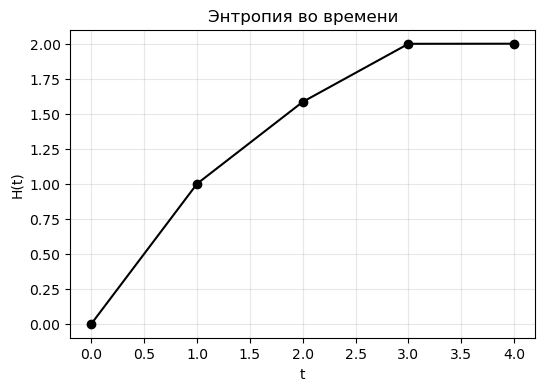

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import log2

def H(p):
    return -sum(pi * log2(pi) for pi in p if pi > 0)

p1 = [0.5, 0.5]
p2 = [1.0, 0.0]
p3 = [0.8, 0.2]

print(H(p1))
print(H(p2))
print(H(p3))

xs = np.linspace(0.001, 0.999, 500)
ys = [H([x, 1 - x]) for x in xs]

plt.figure(figsize=(6, 4))
plt.plot(xs, ys, color='black')
plt.xlabel('p')
plt.ylabel('H(p, 1-p)')
plt.title('Энтропия двухточечного распределения')
plt.grid(True, alpha=0.3)
plt.show()

pA = [0.5, 0.5]
pB = [1/3, 1/3, 1/3]
HA = H(pA)
HB = H(pB)
Hjoint = H([a * b for a in pA for b in pB])

print(HA + HB)
print(Hjoint)

cells = 4
p_initial = [1.0] + [0.0] * (cells - 1)
p_final = [1.0 / cells] * cells

print(H(p_initial))
print(H(p_final))

t = np.arange(0, 5)
Ht = [H(p_initial)] + [H([0.5, 0.5] + [0.0] * (cells - 2))] + [H([0.33, 0.33, 0.34, 0.0])] + [H([0.26, 0.25, 0.25, 0.24])] + [H(p_final)]

plt.figure(figsize=(6, 4))
plt.plot(t, Ht, 'ko-')
plt.xlabel('t')
plt.ylabel('H(t)')
plt.title('Энтропия во времени')
plt.grid(True, alpha=0.3)
plt.show()

-0.0
3.933323512398267
5.0


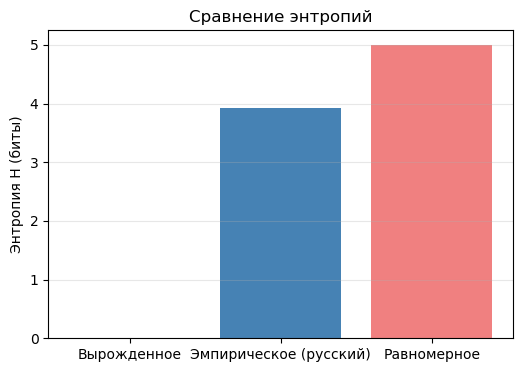

5.0
0.21333529752034663


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from math import log2

def H(p):
    return -sum(pi * log2(pi) for pi in p if pi > 0)

freq_ru = {
    'о': 0.090, 'е': 0.072, 'а': 0.062, 'и': 0.062, 'н': 0.053,
    'т': 0.053, 'с': 0.045, 'р': 0.040, 'в': 0.038, 'л': 0.035,
    'к': 0.028, 'м': 0.026, 'д': 0.025, 'п': 0.023, 'у': 0.021,
    'я': 0.018, 'ы': 0.017, 'ь': 0.015, 'г': 0.014, 'з': 0.014,
    'б': 0.012, 'ч': 0.012, 'й': 0.010, 'х': 0.009, 'ж': 0.008,
    'ш': 0.007, 'ю': 0.006, 'ц': 0.004, 'щ': 0.003, 'э': 0.003,
    'ф': 0.002, 'ъ': 0.001
}

p_empirical = list(freq_ru.values())
p_uniform = [1/len(p_empirical)] * len(p_empirical)
p_delta = [1.0] + [0.0] * (len(p_empirical) - 1)

H_emp = H(p_empirical)
H_unif = H(p_uniform)
H_det = H(p_delta)

print(H_det)
print(H_emp)
print(H_unif)

labels = ['Вырожденное', 'Эмпирическое (русский)', 'Равномерное']
values = [H_det, H_emp, H_unif]

plt.figure(figsize=(6, 4))
plt.bar(labels, values, color=['gray', 'steelblue', 'lightcoral'])
plt.ylabel('Энтропия H (биты)')
plt.title('Сравнение энтропий')
plt.grid(axis='y', alpha=0.3)
plt.show()

alphabet_size = len(p_empirical)
max_possible = log2(alphabet_size)
redundancy = 1 - H_emp / max_possible

print(max_possible)
print(redundancy)